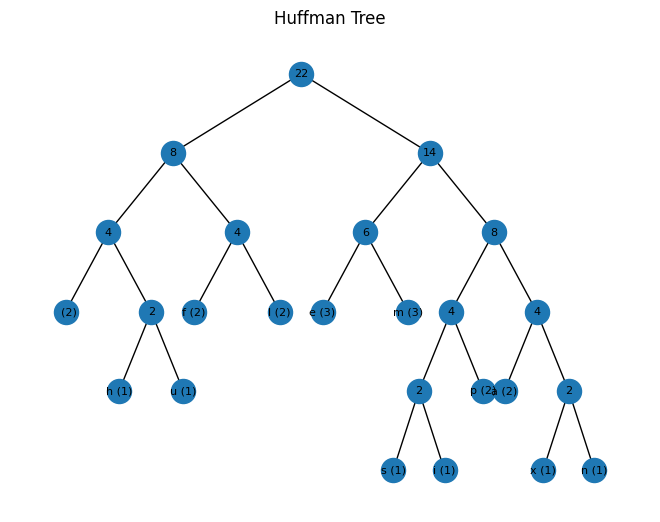

In [ ]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# Step 1: Create a Node class
class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

# Step 2: Build the Huffman Tree
def build_huffman_tree(frequency):
    heap = [Node(char, freq) for char, freq in frequency.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

# Step 3: Visualize the tree
def visualize_huffman_tree(node):
    graph = nx.Graph()
    pos = {}

    def add_nodes_edges(node, x=0, y=0, layer=1):
        if node:
            pos[(x, y)] = (x, y)
            if node.char:
                label = f"{node.char} ({node.freq})"
            else:
                label = str(node.freq)

            labels[(x, y)] = label

            if node.left:
                graph.add_edge((x, y), (x - 2 / layer, y - 1))
                add_nodes_edges(node.left, x - 2 / layer, y - 1, layer + 1)
            if node.right:
                graph.add_edge((x, y), (x + 2 / layer, y - 1))
                add_nodes_edges(node.right, x + 2 / layer, y - 1, layer + 1)

    labels = {}
    add_nodes_edges(node)

    nx.draw(graph, pos, with_labels=False)
    nx.draw_networkx_labels(graph, pos, labels, font_size=8)
    plt.title("Huffman Tree")
    plt.show()

# Example usage
data = "simple huffman example"
frequency = {char: data.count(char) for char in set(data)}
root = build_huffman_tree(frequency)

# Visualize the tree
visualize_huffman_tree(root)


Huffman Codes:
72: 00000
34: 000010
15: 000011
156: 00010
151: 000110
83: 000111
63: 00100
225: 001010
14: 001011
162: 001100
90: 001101
98: 001110
164: 001111
100: 010000
42: 010001
202: 010010
106: 010011
54: 010100
28: 010101
197: 01011
158: 011000
86: 011001
11: 011010
138: 011011
116: 011100
239: 011101
240: 01111
139: 100000
78: 100001
123: 100010
254: 100011
252: 100100
130: 100101
241: 100110
122: 100111
140: 101000
29: 101001
243: 10101
249: 101100
248: 101101
213: 10111
208: 11000
111: 110010
46: 110011
221: 110100
115: 110101
217: 110110
204: 110111
40: 111000
161: 111001
218: 111010
113: 111011
201: 111100
195: 111101
26: 111110
170: 111111

Original frame:
[[ 14 164 130 243 248 213 162 116]
 [201 100 197 240  72  86 241 218]
 [111  63 252  15  34  63  83  72]
 [254  98 204 158  78 138  42 240]
 [197 225 115 156 106 239 123 217]
 [ 40 156  26  11 151 113 139  54]
 [208 170 202 213 140 208 221  29]
 [ 46 161  28 243 195  90 122 249]]

Compressed data:
00101100111110010110101

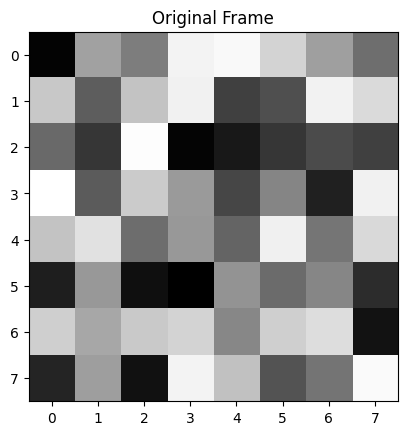

In [ ]:
import heapq
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 1: Define the Node class for the Huffman tree
class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

# Step 2: Build the Huffman tree
def build_huffman_tree(frequency):
    heap = [Node(char, freq) for char, freq in frequency.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

# Step 3: Generate Huffman codes
def generate_codes(node, prefix="", codebook={}):
    if node:
        if node.char is not None:
            codebook[node.char] = prefix
        generate_codes(node.left, prefix + "0", codebook)
        generate_codes(node.right, prefix + "1", codebook)
    return codebook

# Step 4: Compress a frame using Huffman coding
def compress_frame(frame, codebook):
    compressed_data = ''.join([codebook[pixel] for pixel in frame.flatten()])
    return compressed_data

# Step 5: Create a frequency table for a frame
def create_frequency_table(frame):
    unique, counts = np.unique(frame, return_counts=True)
    return dict(zip(unique, counts))

# Step 6: Example usage with a simple video frame
# For simplicity, we use grayscale frames here
frame = np.random.randint(0, 256, (8, 8), dtype=np.uint8)  # Replace this with actual frame data

# Create the frequency table and build the Huffman tree
frequency_table = create_frequency_table(frame)
root = build_huffman_tree(frequency_table)
codes = generate_codes(root)

# Compress the frame
compressed_frame = compress_frame(frame, codes)

# Print results
print("Huffman Codes:")
for char, code in codes.items():
    print(f"{char}: {code}")

print("\nOriginal frame:")
print(frame)
print("\nCompressed data:")
print(compressed_frame)

# Visualize the original frame
plt.imshow(frame, cmap='gray')
plt.title('Original Frame')
plt.show()
